In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
from chemevo import evolution as evo

params = {
   'axes.labelsize': 15,
   'font.size': 15,
   'legend.fontsize': 14,
   'xtick.minor.visible': True,
   'ytick.minor.visible': True,
   'xtick.labelsize': 15,
   'ytick.labelsize': 15,
   'text.usetex': True, #to use TeX in your labels
   'font.family':'serif',
   'axes.titlesize': 15,
   'xtick.direction': 'in',
   'ytick.direction': 'in',
   'xtick.top': True,
   'ytick.right': True,
   'xtick.major.size': 6,
   'xtick.minor.size': 3,
   'ytick.major.size': 6,
   'ytick.minor.size': 3
   }
rcParams.update(params)

colors = ["#0072B2", "#E69F00", "#009E73", "#D55E00", "#CC79A7", "#F0E442"]
linestyles = ['-', '--', ':', '-.']

# Questions for this notebook

<font size="5">

1) How does a change in $\tau_{*}, \eta, \tau_{sfh}, \tau_{Ia}$ change our results for Mn, O, and Fe?
2) Are these changes different for constant vs. exponential SFR?
3) For a set of parameters, possibly a high $\tau_{*}$ and low $\eta$, how does a change in $\alpha_{cc}$ change our results?
4) Same question as above, but for $\alpha_{Ia}$?
5) Same question as above, for $R_{Ia}^{X}$?
6) If I choose two different sets of parameters to represent high alpha (higher $\tau_{*}$, lower $\eta$) and low alpha populations, can I see the same behavior as figure 16 in W2019?
7) If I choose $\alpha_{Ia} = 0$, do I see the same results as Figure 16 W2019?

</font>  

# 1) Constant SFR

In [85]:
t_array = np.linspace(0.0001,12,int(1e3))
tau_sfh = 6 #Gyrs
m_g_array_exp = 1 * np.exp(-t_array/tau_sfh)
m_g_array_const = np.ones(len(t_array))

#Default Galaxies
gal_def_c = evo.Galaxy(t_array=t_array, m_g_array=m_g_array_const)
gal_def_e = evo.Galaxy(t_array=t_array, m_g_array=m_g_array_exp)

def_tau_star = gal_def_c.tau_star_arr[0]
def_eta = gal_def_c.eta_arr[0]
def_tau_sfh = gal_def_c.tau_sfh_arr[0]

def_solarFe = gal_def_c.SolarFe
def_solarO = gal_def_c.SolarO
def_solarMn = gal_def_c.SolarMn

tau_stars = [0.5, 1, 2, 5, 10]
etas = [0.5, 1.5, 2.5, 5]
tau_sfhs = [1, 6, 12]
m_g_array_exps = []
for tau_sfh in tau_sfhs:
    m_g_array_exps.append(1 * np.exp(-t_array/tau_sfh))

print("Default values for: ")
print("eta = ", def_eta)
print("tau_star = ", def_tau_star)
print("tau_sfh = ", def_tau_sfh)

Default values for: 
eta =  2.5
tau_star =  1.0
tau_sfh =  6.0


In [ ]:
#First [] is eta and second [] is tau_star
gal_cs = {
    eta: {
        tau_star: evo.Galaxy(
            t_array=t_array,
            m_g_array=m_g_array_const,
            tau_star=tau_star,
            eta=eta
        )
        for tau_star in tau_stars
    }
    for eta in etas
}

gal_es = {
    eta: {
        tau_star: evo.Galaxy(
            t_array=t_array,
            m_g_array=m_g_array_exp,
            tau_star=tau_star,
            eta=eta
        )
        for tau_star in tau_stars
    }
    for eta in etas
}

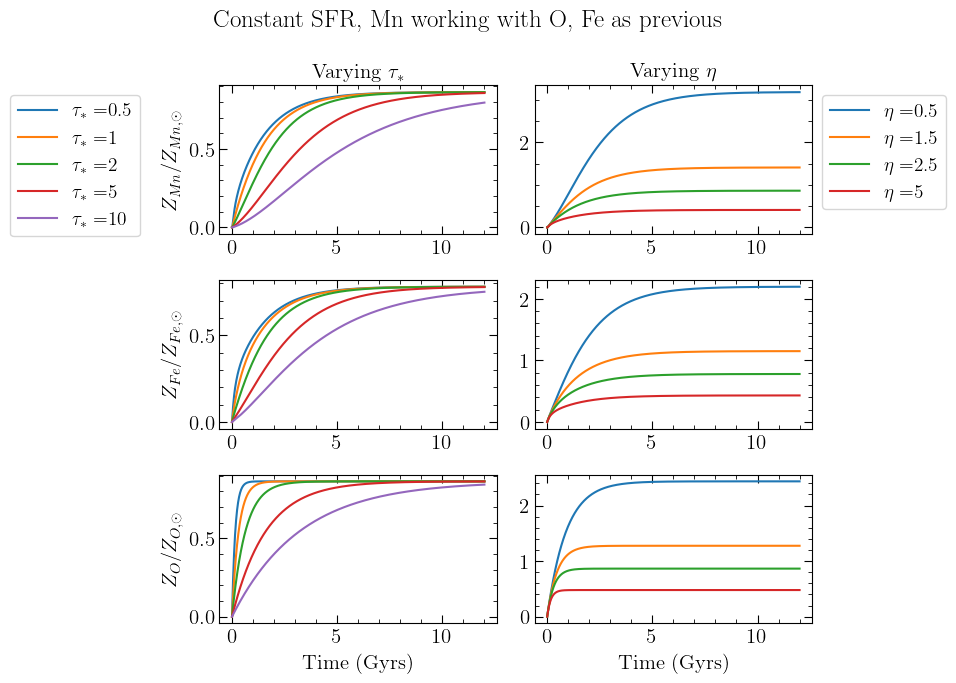

In [48]:
plt.figure(figsize=(10,7))

plt.subplot(3,2,1)
for i in range(len(tau_stars)):
    plt.plot(t_array, gal_cs[2.5][tau_stars[i]].compute_z_X()/def_solarMn, label = r'$\tau_{*} = $' + f"{tau_stars[i]}")
plt.title(r"Varying $\tau_{*}$")
plt.ylabel(r"$Z_{Mn}/Z_{Mn,\odot}$")
plt.legend(loc='upper right', bbox_to_anchor=(-0.25, 1.0))

plt.subplot(3,2,2)
for i in range(len(etas)):
    plt.plot(t_array, gal_cs[etas[i]][1].compute_z_X()/def_solarMn, label = r'$\eta = $' + f"{etas[i]}")
plt.title(r"Varying $\eta$")
plt.legend(loc='upper left', bbox_to_anchor=[1,1])


plt.subplot(3,2,3)
for i in range(len(tau_stars)):
    plt.plot(t_array, gal_cs[2.5][tau_stars[i]].compute_z_Fe()/def_solarFe)
plt.ylabel(r"$Z_{Fe}/Z_{Fe,\odot}$")

plt.subplot(3,2,4)
for i in range(len(etas)):
    plt.plot(t_array, gal_cs[etas[i]][1].compute_z_Fe()/def_solarFe)

plt.subplot(3,2,5)
for i in range(len(tau_stars)):
    plt.plot(t_array, gal_cs[2.5][tau_stars[i]].compute_z_O()/def_solarO)
plt.xlabel('Time (Gyrs)')
plt.ylabel(r"$Z_{O}/Z_{O,\odot}$")

plt.subplot(3,2,6)
for i in range(len(etas)):
    plt.plot(t_array, gal_cs[etas[i]][1].compute_z_O()/def_solarO)
plt.xlabel("Time (Gyrs)")

plt.suptitle("Constant SFR, Mn working with O, Fe as previous")
plt.tight_layout()

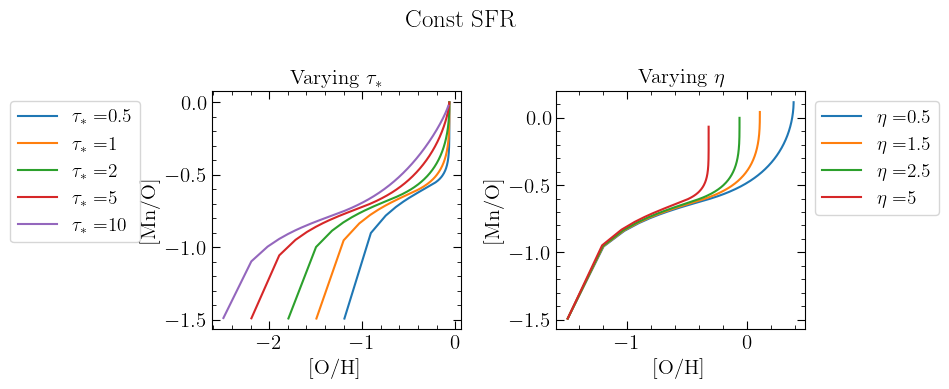

In [81]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
for i in range(len(tau_stars)):
    plt.plot(gal_cs[2.5][tau_stars[i]].O_H[1:], gal_cs[2.5][tau_stars[i]].Mn_O[1:], label = r'$\tau_{*} = $' + f"{tau_stars[i]}")
plt.title(r"Varying $\tau_{*}$")
plt.ylabel("[Mn/O]")
plt.xlabel("[O/H]")
plt.legend(loc='upper right', bbox_to_anchor=(-0.25, 1.0))

plt.subplot(1,2,2)
for i in range(len(etas)):
    plt.plot(gal_cs[etas[i]][1].O_H[1:], gal_cs[etas[i]][1].Mn_O[1:], label = r'$\eta = $' + f"{etas[i]}")
plt.ylabel("[Mn/O]")
plt.xlabel("[O/H]")
plt.title(r"Varying $\eta$")
plt.legend(loc='upper left', bbox_to_anchor=[1,1])

plt.suptitle("Const SFR")
plt.tight_layout()

Text(0.5, 1.02, 'Constant SFR — [Mn/O] vs [O/H] for varying $\\eta$ and $\\tau_{star}$')

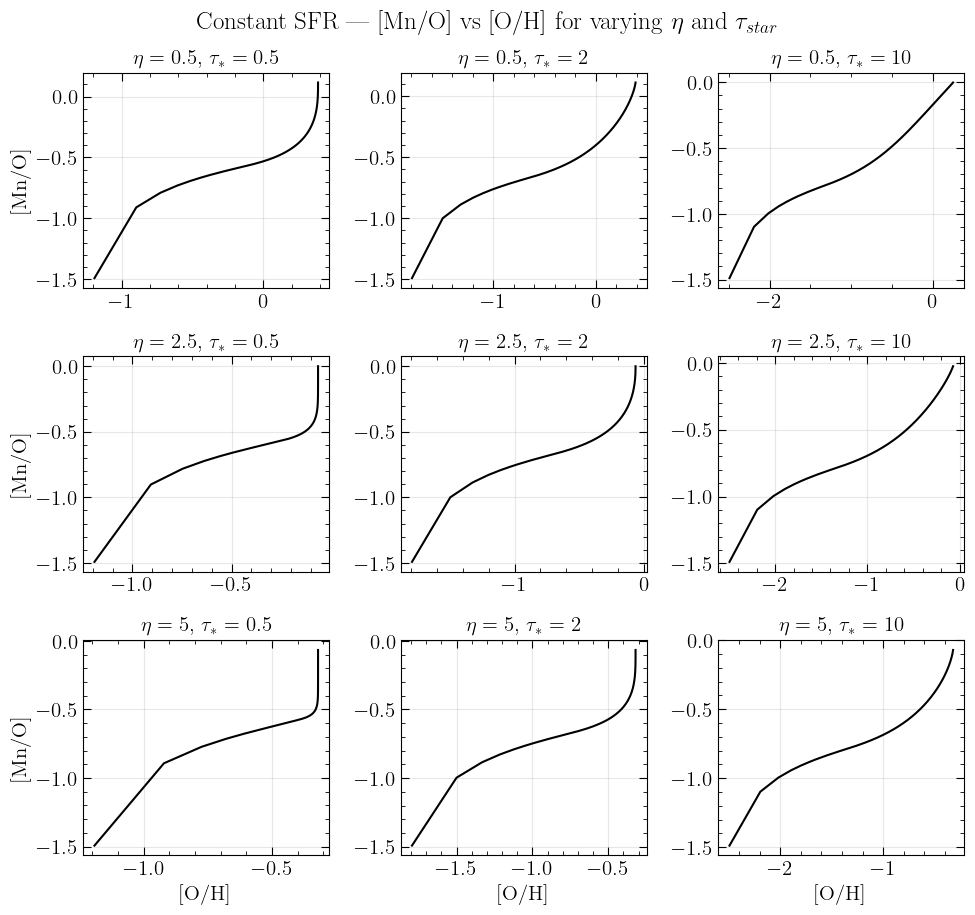

In [60]:
import matplotlib.pyplot as plt

tau_stars_plot = [0.5, 2, 10]
etas_plot = [0.5, 2.5, 5]

plt.figure(figsize=(10, 9))

for i, eta in enumerate(etas_plot):
    for j, tau_star in enumerate(tau_stars_plot):
        ax = plt.subplot(3, 3, i*3 + j + 1)
        
        gal = gal_cs[eta][tau_star]
        plt.plot(gal.O_H[1:], gal.Mn_O[1:], color='black')
        
        # Axis labels
        if i == 2:  # bottom row
            plt.xlabel("[O/H]")
        if j == 0:  # first column
            plt.ylabel("[Mn/O]")
        
        # Titles
        plt.title(rf"$\eta = {eta}$, $\tau_{{*}} = {tau_star}$", fontsize=15)
        
        # Style tweaks
        plt.grid(alpha=0.3)
        plt.tight_layout()

plt.suptitle(r"Constant SFR — [Mn/O] vs [O/H] for varying $\eta$ and $\tau_{star}$", y=1.02)

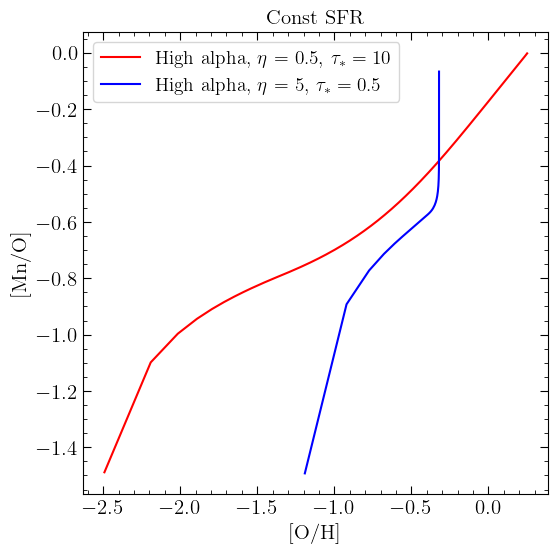

In [77]:
plt.figure(figsize=(6,6))

#High alpha, higher tau_star and lower eta
#Low alpha, lower tau_star and higher eta
tau_star_high_alpha = 10
eta_high_alpha = 0.5

tau_star_low_alpha = 0.5
eta_low_alpha = 5

plt.plot(gal_cs[eta_high_alpha][tau_star_high_alpha].O_H[1:], gal_cs[eta_high_alpha][tau_star_high_alpha].Mn_O[1:],
         label = rf"High alpha, $\eta$ = {eta_high_alpha}, $\tau_* = {tau_star_high_alpha}$", color = 'red')
plt.plot(gal_cs[eta_low_alpha][tau_star_low_alpha].O_H[1:], gal_cs[eta_low_alpha][tau_star_low_alpha].Mn_O[1:],
         label = rf"High alpha, $\eta$ = {eta_low_alpha}, $\tau_* = {tau_star_low_alpha}$", color = 'blue')

plt.title("Const SFR")
plt.ylabel("[Mn/O]")
plt.xlabel("[O/H]")
plt.legend(loc='upper left')

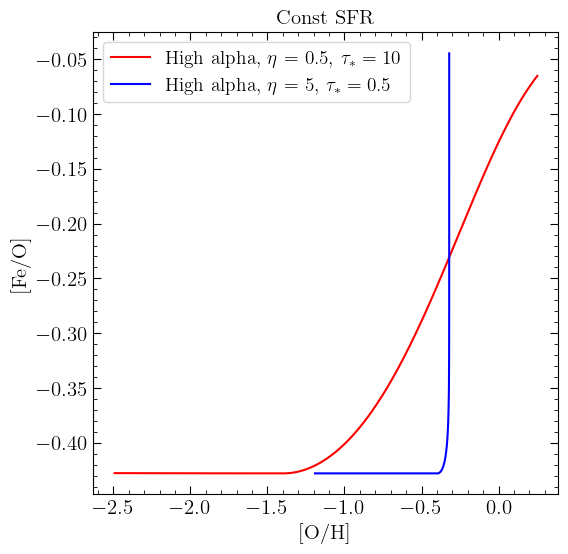

In [78]:
plt.figure(figsize=(6,6))

#High alpha, higher tau_star and lower eta
#Low alpha, lower tau_star and higher eta
tau_star_high_alpha = 10
eta_high_alpha = 0.5

tau_star_low_alpha = 0.5
eta_low_alpha = 5

plt.plot(gal_cs[eta_high_alpha][tau_star_high_alpha].O_H[1:], gal_cs[eta_high_alpha][tau_star_high_alpha].Fe_O[1:],
         label = rf"High alpha, $\eta$ = {eta_high_alpha}, $\tau_* = {tau_star_high_alpha}$", color = 'red')
plt.plot(gal_cs[eta_low_alpha][tau_star_low_alpha].O_H[1:], gal_cs[eta_low_alpha][tau_star_low_alpha].Fe_O[1:],
         label = rf"High alpha, $\eta$ = {eta_low_alpha}, $\tau_* = {tau_star_low_alpha}$", color = 'blue')

plt.title("Const SFR")
plt.ylabel("[Fe/O]")
plt.xlabel("[O/H]")
plt.legend(loc='upper left')

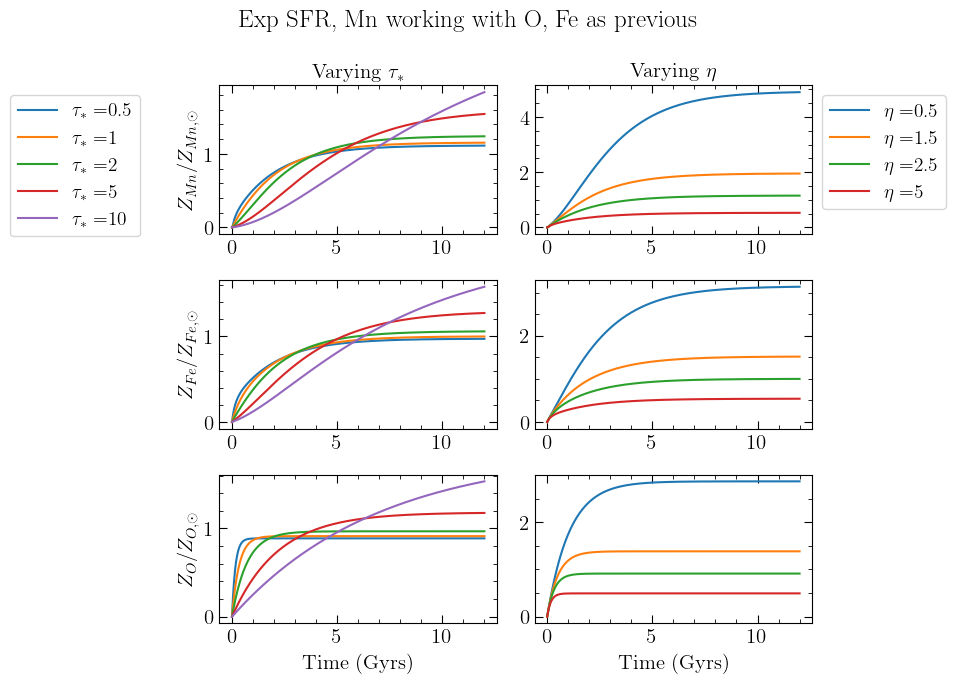

In [80]:
plt.figure(figsize=(10,7))

plt.subplot(3,2,1)
for i in range(len(tau_stars)):
    plt.plot(t_array, gal_es[2.5][tau_stars[i]].compute_z_X()/def_solarMn, label = r'$\tau_{*} = $' + f"{tau_stars[i]}")
plt.title(r"Varying $\tau_{*}$")
plt.ylabel(r"$Z_{Mn}/Z_{Mn,\odot}$")
plt.legend(loc='upper right', bbox_to_anchor=(-0.25, 1.0))

plt.subplot(3,2,2)
for i in range(len(etas)):
    plt.plot(t_array, gal_es[etas[i]][1].compute_z_X()/def_solarMn, label = r'$\eta = $' + f"{etas[i]}")
plt.title(r"Varying $\eta$")
plt.legend(loc='upper left', bbox_to_anchor=[1,1])


plt.subplot(3,2,3)
for i in range(len(tau_stars)):
    plt.plot(t_array, gal_es[2.5][tau_stars[i]].compute_z_Fe()/def_solarFe)
plt.ylabel(r"$Z_{Fe}/Z_{Fe,\odot}$")

plt.subplot(3,2,4)
for i in range(len(etas)):
    plt.plot(t_array, gal_es[etas[i]][1].compute_z_Fe()/def_solarFe)

plt.subplot(3,2,5)
for i in range(len(tau_stars)):
    plt.plot(t_array, gal_es[2.5][tau_stars[i]].compute_z_O()/def_solarO)
plt.xlabel('Time (Gyrs)')
plt.ylabel(r"$Z_{O}/Z_{O,\odot}$")

plt.subplot(3,2,6)
for i in range(len(etas)):
    plt.plot(t_array, gal_es[etas[i]][1].compute_z_O()/def_solarO)
plt.xlabel("Time (Gyrs)")

plt.suptitle("Exp SFR, Mn working with O, Fe as previous")
plt.tight_layout()

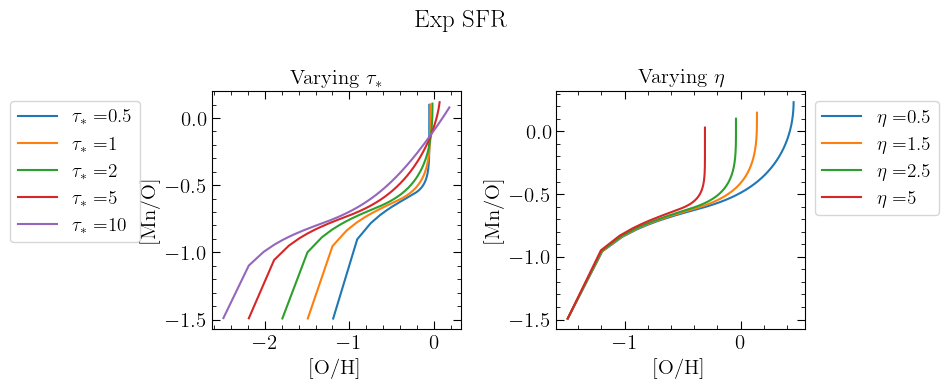

In [82]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
for i in range(len(tau_stars)):
    plt.plot(gal_es[2.5][tau_stars[i]].O_H[1:], gal_es[2.5][tau_stars[i]].Mn_O[1:], label = r'$\tau_{*} = $' + f"{tau_stars[i]}")
plt.title(r"Varying $\tau_{*}$")
plt.ylabel("[Mn/O]")
plt.xlabel("[O/H]")
plt.legend(loc='upper right', bbox_to_anchor=(-0.25, 1.0))

plt.subplot(1,2,2)
for i in range(len(etas)):
    plt.plot(gal_es[etas[i]][1].O_H[1:], gal_es[etas[i]][1].Mn_O[1:], label = r'$\eta = $' + f"{etas[i]}")
plt.ylabel("[Mn/O]")
plt.xlabel("[O/H]")
plt.title(r"Varying $\eta$")
plt.legend(loc='upper left', bbox_to_anchor=[1,1])

plt.suptitle("Exp SFR")
plt.tight_layout()

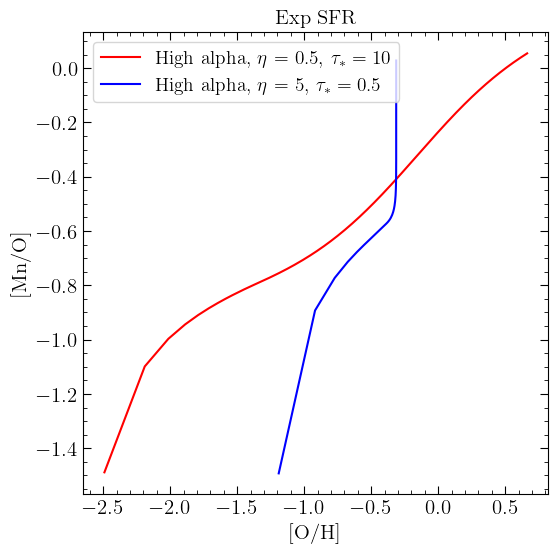

In [83]:
plt.figure(figsize=(6,6))

#High alpha, higher tau_star and lower eta
#Low alpha, lower tau_star and higher eta
tau_star_high_alpha = 10
eta_high_alpha = 0.5

tau_star_low_alpha = 0.5
eta_low_alpha = 5

plt.plot(gal_es[eta_high_alpha][tau_star_high_alpha].O_H[1:], gal_es[eta_high_alpha][tau_star_high_alpha].Mn_O[1:],
         label = rf"High alpha, $\eta$ = {eta_high_alpha}, $\tau_* = {tau_star_high_alpha}$", color = 'red')
plt.plot(gal_es[eta_low_alpha][tau_star_low_alpha].O_H[1:], gal_es[eta_low_alpha][tau_star_low_alpha].Mn_O[1:],
         label = rf"High alpha, $\eta$ = {eta_low_alpha}, $\tau_* = {tau_star_low_alpha}$", color = 'blue')

plt.title("Exp SFR")
plt.ylabel("[Mn/O]")
plt.xlabel("[O/H]")
plt.legend(loc='upper left')

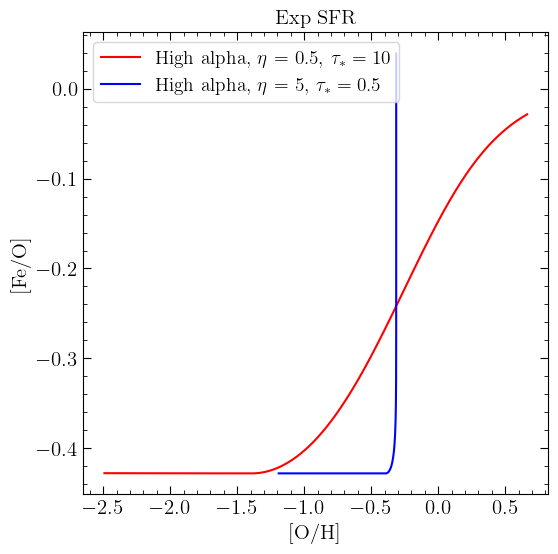

In [88]:
plt.figure(figsize=(6,6))

#High alpha, higher tau_star and lower eta
#Low alpha, lower tau_star and higher eta
tau_star_high_alpha = 10
eta_high_alpha = 0.5

tau_star_low_alpha = 0.5
eta_low_alpha = 5

plt.plot(gal_es[eta_high_alpha][tau_star_high_alpha].O_H[1:], gal_es[eta_high_alpha][tau_star_high_alpha].Fe_O[1:],
         label = rf"High alpha, $\eta$ = {eta_high_alpha}, $\tau_* = {tau_star_high_alpha}$", color = 'red')
plt.plot(gal_es[eta_low_alpha][tau_star_low_alpha].O_H[1:], gal_es[eta_low_alpha][tau_star_low_alpha].Fe_O[1:],
         label = rf"High alpha, $\eta$ = {eta_low_alpha}, $\tau_* = {tau_star_low_alpha}$", color = 'blue')

plt.title("Exp SFR")
plt.ylabel("[Fe/O]")
plt.xlabel("[O/H]")
plt.legend(loc='upper left')

In [113]:
tau_Ia_def = gal_def_e.tau_Ia_arr[0]
print(tau_Ia_def)
tau_Ia_bigger = 1
gal_es_varsfh = {
    tau_sfh_var: {
        eta: {
            tau_star: evo.Galaxy(
                t_array=t_array,
                m_g_array=1 * np.exp(-t_array/tau_sfh_var),
                tau_star=tau_star,
                eta=eta,
                tau_Ia=tau_Ia_bigger
            )
            for tau_star in tau_stars
        }
        for eta in etas
    }
    for tau_sfh_var in tau_sfhs
}

1.5


In [118]:
print("etas = ", etas)
print("tau_stars = ", tau_stars)

etas =  [0.5, 1.5, 2.5, 5]
tau_stars =  [0.5, 1, 2, 5, 10]


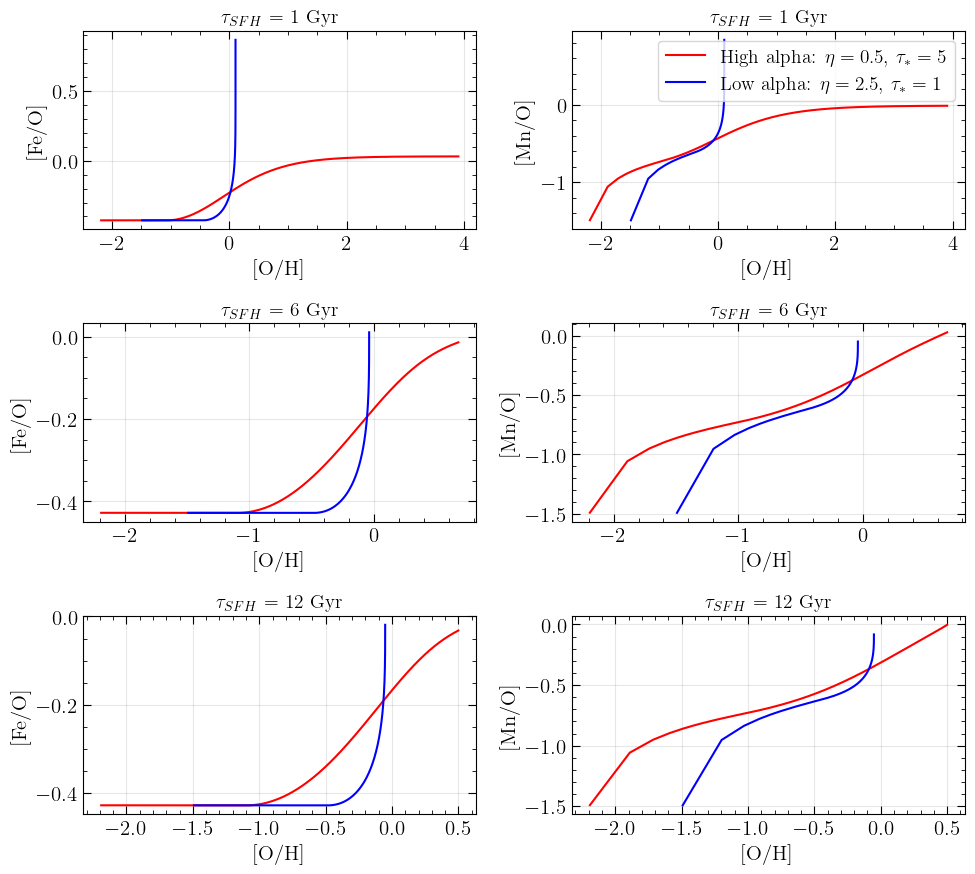

In [120]:
plt.figure(figsize=(10, 9))

# Define characteristic cases
tau_star_high_alpha = 5
eta_high_alpha = 0.5

tau_star_low_alpha = 1
eta_low_alpha = 2.5

for i, tau_sfh in enumerate(tau_sfhs[:3]):  # only 3 tau_sfh values
    # --- Left column: [Fe/O] ---
    plt.subplot(3, 2, 2*i + 1)
    gal_high = gal_es_varsfh[tau_sfh][eta_high_alpha][tau_star_high_alpha]
    gal_low  = gal_es_varsfh[tau_sfh][eta_low_alpha][tau_star_low_alpha]
    
    plt.plot(gal_high.O_H[1:], gal_high.Fe_O[1:], color='red',
             label=rf"High alpha: $\eta={eta_high_alpha}$, $\tau_*={tau_star_high_alpha}$")
    plt.plot(gal_low.O_H[1:], gal_low.Fe_O[1:], color='blue',
             label=rf"Low alpha: $\eta={eta_low_alpha}$, $\tau_*={tau_star_low_alpha}$")
    
    plt.title(rf"$\tau_{{SFH}}$ = {tau_sfh} Gyr", fontsize=14)
    plt.ylabel("[Fe/O]")
    plt.xlabel("[O/H]")
    plt.grid(alpha=0.3)
    
    # --- Right column: [Mn/O] ---
    plt.subplot(3, 2, 2*i + 2)
    gal_high = gal_es_varsfh[tau_sfh][eta_high_alpha][tau_star_high_alpha]
    gal_low  = gal_es_varsfh[tau_sfh][eta_low_alpha][tau_star_low_alpha]
    
    plt.plot(gal_high.O_H[1:], gal_high.Mn_O[1:], color='red',
             label=rf"High alpha: $\eta={eta_high_alpha}$, $\tau_*={tau_star_high_alpha}$")
    plt.plot(gal_low.O_H[1:], gal_low.Mn_O[1:], color='blue',
             label=rf"Low alpha: $\eta={eta_low_alpha}$, $\tau_*={tau_star_low_alpha}$")
    
    plt.title(rf"$\tau_{{SFH}}$ = {tau_sfh} Gyr", fontsize=14)
    plt.ylabel("[Mn/O]")
    plt.xlabel("[O/H]")
    plt.grid(alpha=0.3)
    if i == 0:
        plt.legend(loc='upper right')


plt.tight_layout()

# Now let's do some experiments with alpha_Ia, alpha_cc, and R_Ia

In [127]:
# For this example galaxy, eta = 1.5 and tau_star = 5
#All Exp SFRs
gal_WAF = gal_es[def_eta][def_tau_star]
gal_eg = gal_es[1.5][5]

alpha_Ias = [-0.1, 0.3, 0.5]
alpha_ccs = [-0.1, 0.2, 0.4]
R_Ias = [0, 1, 8]

Z_Mns = []

#Use it like Z_Mns[alpha_cc][alpha_Ia][R_Ia]
Z_Mns = {
    alpha_cc: {
        alpha_Ia: {
            R_Ia: gal_eg.compute_z_X(alpha_cc_X=alpha_cc, alpha_Ia_X=alpha_Ia, R_Ia_X=R_Ia)
            for R_Ia in R_Ias
        }
        for alpha_Ia in alpha_Ias
    }
    for alpha_cc in alpha_ccs
}

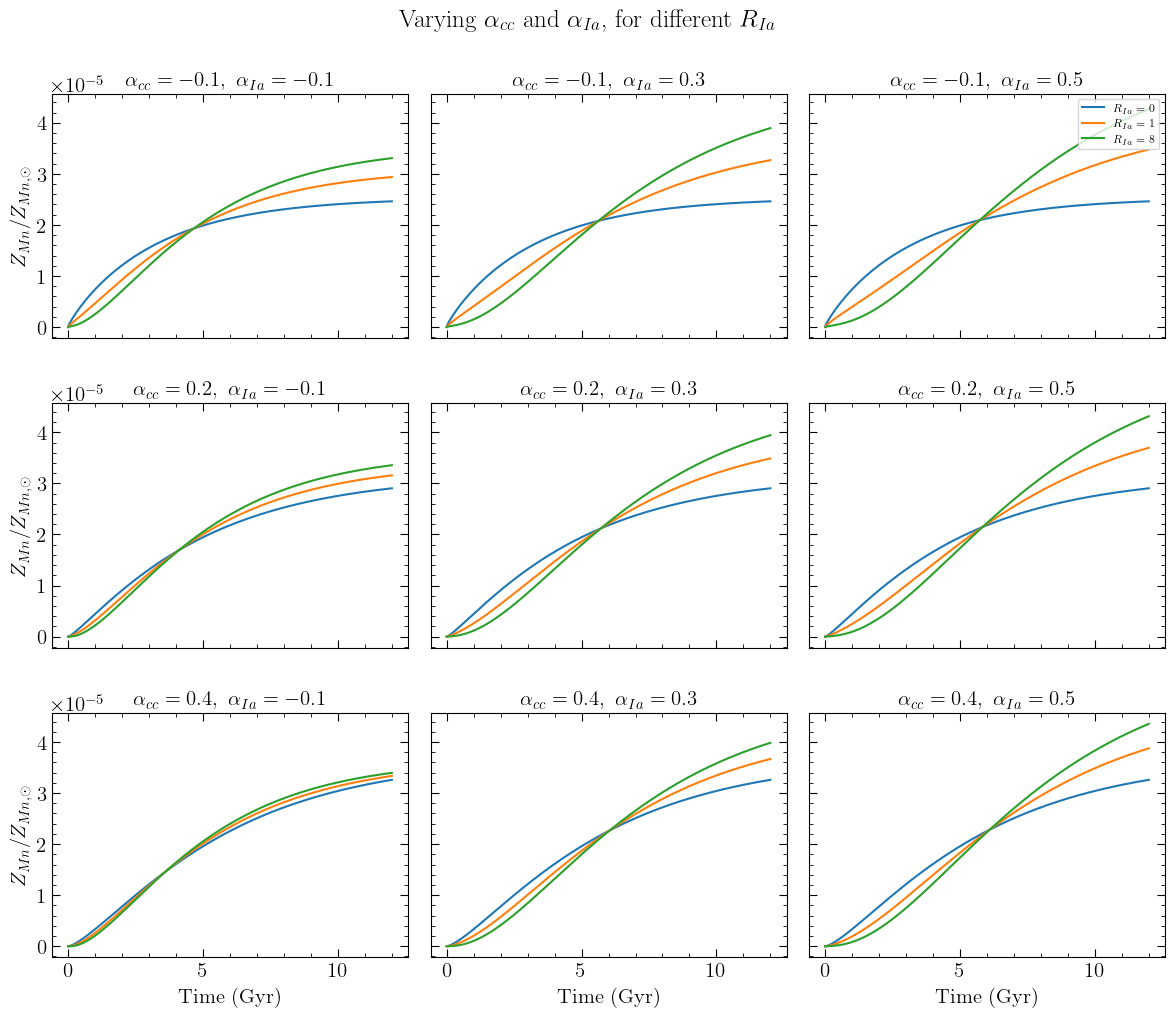

In [129]:
fig, axes = plt.subplots(3, 3, figsize=(12, 10), sharex=True, sharey=True)

for i, alpha_cc in enumerate(alpha_ccs):
    for j, alpha_Ia in enumerate(alpha_Ias):
        ax = axes[i, j]
        for R_Ia in R_Ias:
            ax.plot(
                t_array,
                Z_Mns[alpha_cc][alpha_Ia][R_Ia],
                label=rf"$R_{{Ia}} = {R_Ia}$"
            )
        ax.set_title(rf"$\alpha_{{cc}} = {alpha_cc}, \ \alpha_{{Ia}} = {alpha_Ia}$")
        if i == 2:
            ax.set_xlabel("Time (Gyr)")
        if j == 0:
            ax.set_ylabel(r"$Z_{Mn}/Z_{Mn,\odot}$")
        if i == 0 and j == 2:
            ax.legend(fontsize=8, loc="upper right")

plt.tight_layout()
plt.suptitle(r"Varying $\alpha_{cc}$ and $\alpha_{Ia}$, for different $R_{Ia}$", y=1.02)
plt.show()


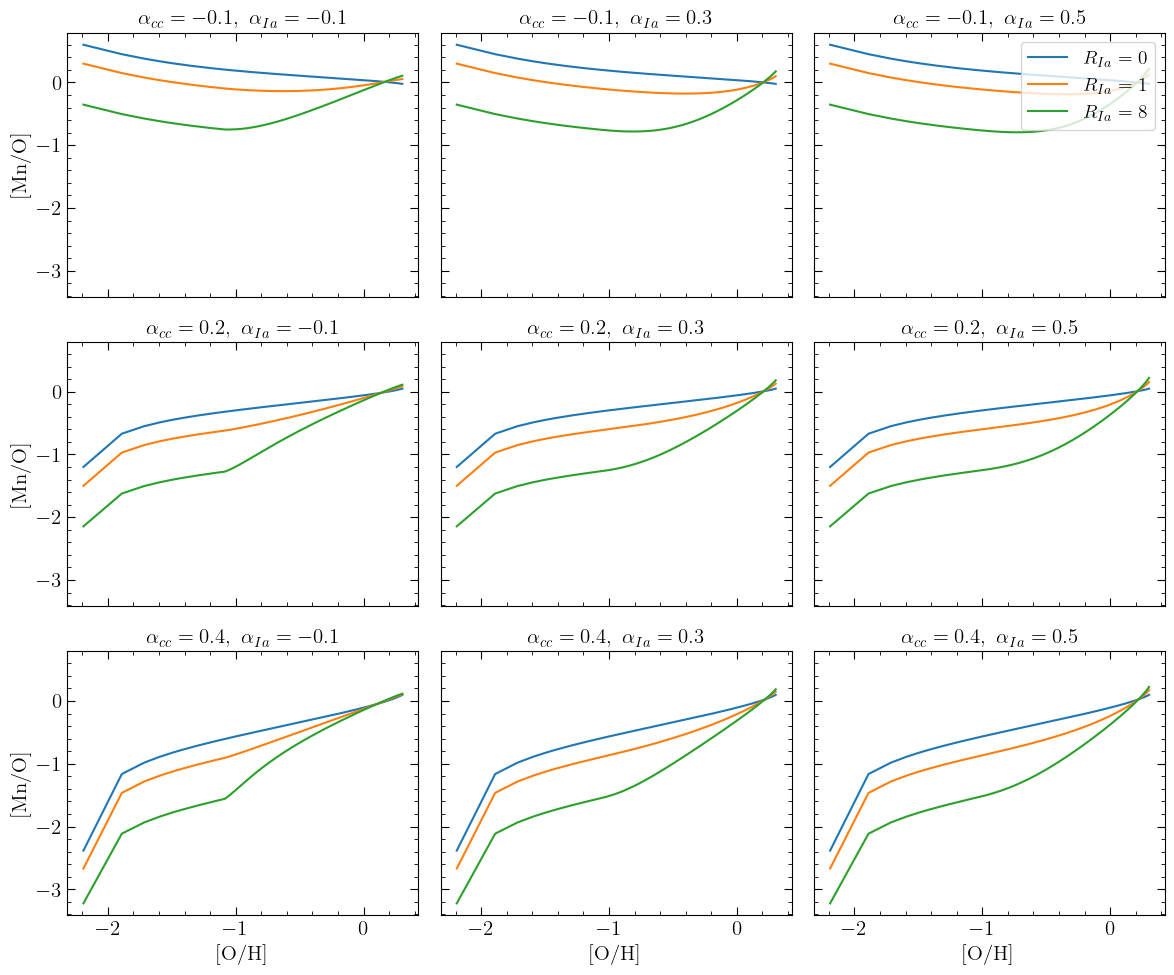

In [131]:
fig, axes = plt.subplots(3, 3, figsize=(12, 10), sharex=True, sharey=True)

for i, alpha_cc in enumerate(alpha_ccs):
    for j, alpha_Ia in enumerate(alpha_Ias):
        ax = axes[i, j]
        for R_Ia in R_Ias:
            ax.plot(
                gal_eg.O_H[1:],
                gal_eg.ratio_to_sun(Z_Mns[alpha_cc][alpha_Ia][R_Ia], def_solarMn)[1:] - gal_eg.O_H[1:],
                label=rf"$R_{{Ia}} = {R_Ia}$"
            )
        ax.set_title(rf"$\alpha_{{cc}} = {alpha_cc}, \ \alpha_{{Ia}} = {alpha_Ia}$")
        if i == 2:
            ax.set_xlabel("[O/H]")
        if j == 0:
            ax.set_ylabel("[Mn/O]")
        if i == 0 and j == 2:
            ax.legend(fontsize=14, loc="upper right")

plt.tight_layout()
plt.show()
